### Step 1 – Plot collected data
Plot the collected CPU utilization, power, latency, and request/failure traces for the experiment as a quick sanity check.


Loading ./executed/2026-ICSA-PE/excessive_dynamic_allocation/202511211453-testexcessivedynamicallocation1/measurements.csv
Saved plot to excessive_dynamic_allocation.pdf


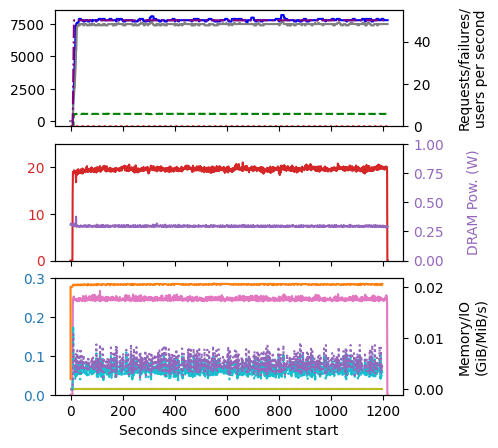

Loading ./executed/2026-ICSA-PE/godclass/202511212323-testgodclass1/measurements.csv
Saved plot to godclass.pdf


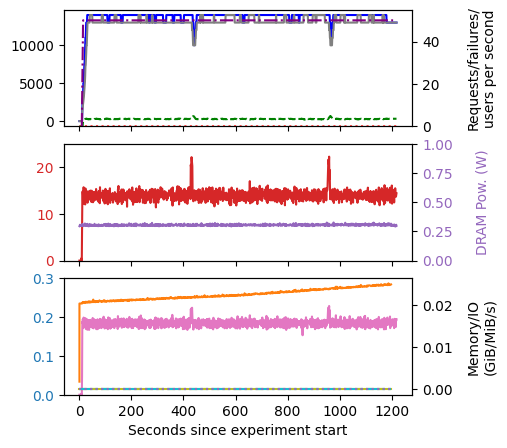

Loading ./executed/2026-ICSA-PE/more_is_less/202511211743-testmoreisless1/measurements.csv
Saved plot to more_is_less.pdf


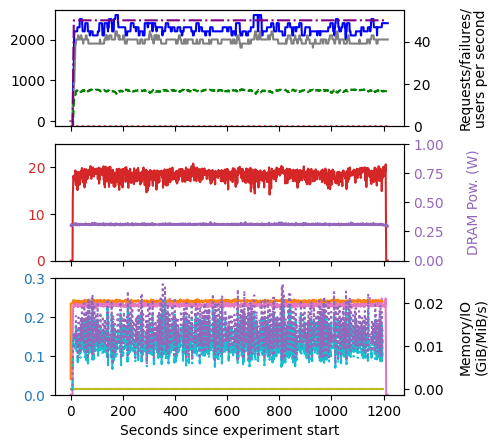

Loading ./executed/2026-ICSA-PE/one_lane_bridge/202511261235-testonelanebridge1/measurements.csv
Saved plot to one_lane_bridge.pdf


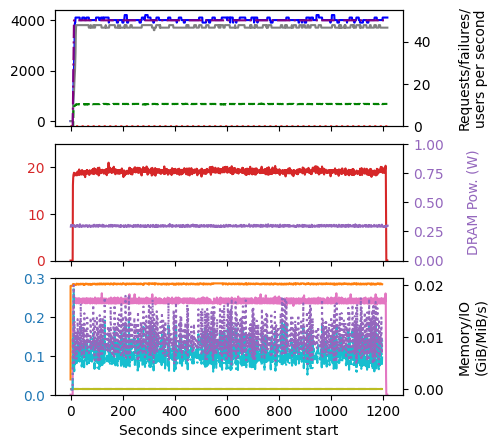

Loading ./executed/2026-ICSA-PE/sisyphus_db_retrieval/202511220213-testsisyphus1/measurements.csv
Saved plot to sisyphus.pdf


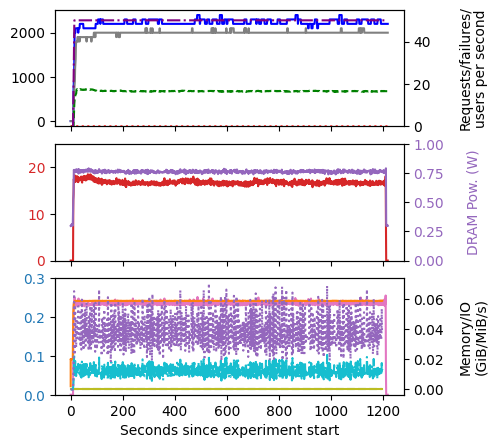

Loading ./executed/2026-ICSA-PE/traffic_jam/202511220503-testtrafficjam1/measurements.csv
Saved plot to traffic_jam.pdf


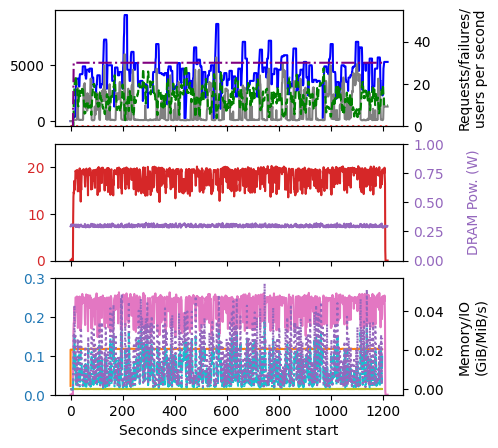

Loading ./executed/2026-ICSA-PE/unbalanced_processing/202511220945-testunbalanced1/measurements.csv
Saved plot to unbalanced_processing.pdf


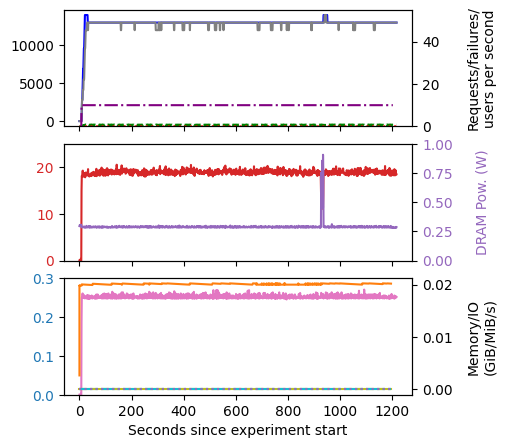

Loading ./executed/2026-ICSA-PE/unnecessary_processing/202511220753-testunnecessary1/measurements.csv
Saved plot to unnecessary_work.pdf


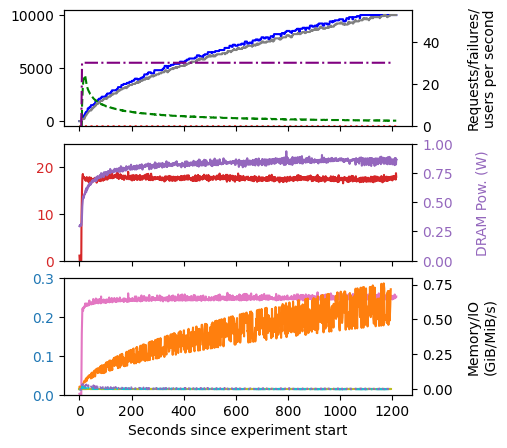

Loading ./executed/2026-ICSA-PE/circuitous_treasure_hunt/202511212033-testcircuitous1/measurements.csv
Saved plot to circuitous_treasure_hunt.pdf


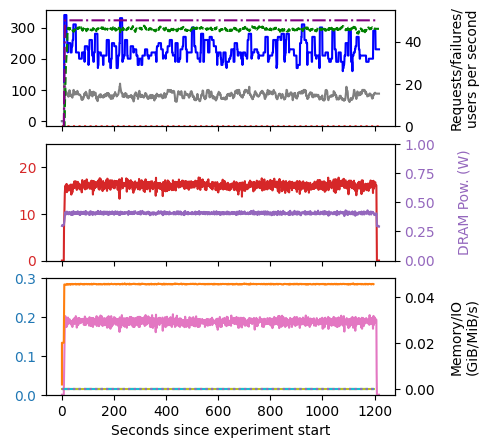

Loading ./executed/2026-ICSA-PE/the_ramp/202511222023-testtheramp1/measurements.csv
Saved plot to the_ramp.pdf


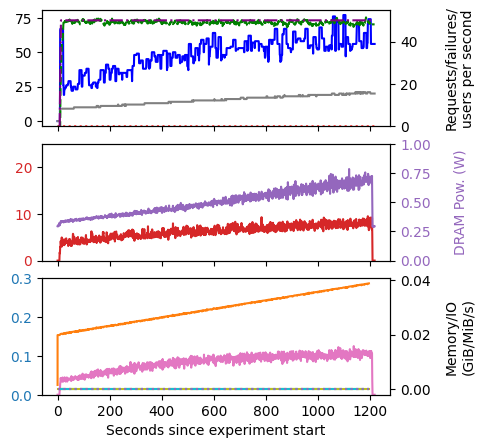

In [11]:
# Step 1: Configure experiment context and plot per-container traces via a helper function.
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

def _compute_io_rate(series, seconds):
    delta = series.diff().clip(lower=0)
    dt = seconds.diff().replace(0, np.nan)
    return (delta / dt).fillna(0)

def plot_experiment(experiment_dir, latency_metric="100%", output_pdf=None):
    hide_left_labels = True
    hide_right_labels = False
    left_label_x = -0.16
    right_label_x = 1.20
    measurements_path = f"{experiment_dir}/measurements.csv"
    locust_history_path = f"{experiment_dir}/result_stats_history.csv"
    cadvisor_container_path = f"{experiment_dir}/cadvisor_container.csv"
    perf_power_path = f"{experiment_dir}/perf_power.csv"
    if not os.path.exists(measurements_path):
        raise FileNotFoundError(f"Measurements file not found at {measurements_path}. Run analyze_performance_energy_prepare.py first.")
    print(f"Loading {measurements_path}")
    measurement_df = pd.read_csv(measurements_path)
    # Drop negative CPU power samples caused by measurement noise.
    if "cpu_power" in measurement_df.columns:
        measurement_df["cpu_power"] = pd.to_numeric(measurement_df["cpu_power"], errors="coerce")
        measurement_df = measurement_df[measurement_df["cpu_power"] >= 0].copy()
    containers = sorted(measurement_df["container_name"].unique()) if "container_name" in measurement_df else []
    output_base = None
    if output_pdf is not None:
        output_base = Path(output_pdf)
        if output_base.suffix.lower() != ".pdf":
            output_base = output_base.with_suffix(".pdf")
    experiment_start_epoch = None
    if "timestamp" in measurement_df.columns:
        measurement_df["timestamp"] = pd.to_datetime(measurement_df["timestamp"], errors="coerce")
        start_ts = measurement_df["timestamp"].dropna().min()
        if pd.notnull(start_ts):
            experiment_start_epoch = start_ts.timestamp()
    history_df = pd.DataFrame()
    if os.path.exists(locust_history_path):
        history_df = pd.read_csv(locust_history_path, usecols=["Timestamp", "User Count", "Name"])
        history_df = history_df[history_df["Name"] == "Aggregated"].copy()
        history_df["Timestamp"] = pd.to_numeric(history_df["Timestamp"], errors="coerce")
        history_df["User Count"] = pd.to_numeric(history_df["User Count"], errors="coerce")
        history_df.dropna(subset=["Timestamp", "User Count"], inplace=True)
        if experiment_start_epoch is None and not history_df.empty:
            experiment_start_epoch = history_df["Timestamp"].min()
    cadvisor_df = pd.DataFrame()
    if os.path.exists(cadvisor_container_path):
        cadvisor_df = pd.read_csv(
            cadvisor_container_path,
            usecols=[
                "timestamp",
                "service",
                "memory_usage",
                "memory_limit",
                "readBytes",
                "writeBytes",
                "rx_bytes",
                "tx_bytes",
            ],
        )
        numeric_cols = [
            "timestamp",
            "memory_usage",
            "memory_limit",
            "readBytes",
            "writeBytes",
            "rx_bytes",
            "tx_bytes",
        ]
        for column in numeric_cols:
            cadvisor_df[column] = pd.to_numeric(cadvisor_df[column], errors="coerce")
        cadvisor_df.dropna(subset=["timestamp", "service"], inplace=True)
        if experiment_start_epoch is None and not cadvisor_df.empty:
            experiment_start_epoch = cadvisor_df["timestamp"].min()
    perf_power_df = pd.DataFrame()
    if os.path.exists(perf_power_path):
        perf_power_df = pd.read_csv(perf_power_path)
        perf_power_df["timestamp_epoch"] = pd.to_numeric(perf_power_df["timestamp_epoch"], errors="coerce")
        perf_power_df["dram_w"] = pd.to_numeric(perf_power_df["dram_w"], errors="coerce")
        perf_power_df.dropna(subset=["timestamp_epoch", "dram_w"], inplace=True)
        if experiment_start_epoch is None and not perf_power_df.empty:
            experiment_start_epoch = perf_power_df["timestamp_epoch"].min()
    if experiment_start_epoch is None:
        experiment_start_epoch = 0.0
    users_over_time = pd.DataFrame(columns=["seconds_from_start", "User Count"])
    if not history_df.empty:
        history_df["seconds_from_start"] = (history_df["Timestamp"] - experiment_start_epoch).clip(lower=0)
        users_over_time = history_df[["seconds_from_start", "User Count"]]
    for container_name, container_plot_df in measurement_df.groupby('container_name'):
        container_plot_df = container_plot_df.sort_values('seconds_from_start').reset_index(drop=True)
        seconds = container_plot_df['seconds_from_start']
        fig, axes = plt.subplots(
            3,
            1,
            figsize=(4.5, 5),
            sharex=True,
            gridspec_kw={'height_ratios': [1, 1, 1], 'hspace': 0.15},
        )
        ax_locust, ax_power, ax_resources = axes
        ax_locust.plot(seconds, container_plot_df['latency'], color='blue', label=f"Resp. time ({latency_metric} percentile)")
        ax_locust.plot(seconds, container_plot_df['latency_p50_ms'], color='gray', label='Resp. time (50% percentile)')
        ax_locust.set_ylabel('Resp. time (ms)')
        
        ax_counts = ax_locust.twinx()
        ax_counts.plot(seconds, container_plot_df['requests_per_s'], color='green', linestyle='--', label='Requests/s')
        ax_counts.plot(seconds, container_plot_df['failures_per_s'], color='red', linestyle=':', label='Failures/s')
        if not users_over_time.empty:
            ax_counts.plot(users_over_time['seconds_from_start'], users_over_time['User Count'], color='purple', linestyle='-.', label='Active users')
        ax_counts.set_ylabel('Requests/failures/\nusers per second')
        ax_counts.set_ylim(0, 55)
        locust_lines = ax_locust.get_lines() + ax_counts.get_lines()
        locust_labels = [line.get_label() for line in locust_lines]
        # ax_locust.legend(locust_lines, locust_labels, loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=len(locust_lines), borderaxespad=0.0, columnspacing=0.6)
#         ax_locust.legend(locust_lines, locust_labels, loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=2, borderaxespad=0.0, columnspacing=0.6)
        # Power subplot: CPU on left axis, DRAM on right axis.
        cpu_power_line, = ax_power.plot(seconds, container_plot_df['cpu_power'], color='tab:red', label='CPU Power (W)')
        ax_dram = ax_power.twinx()
        dram_lines = []
        dram_labels = []
        if not perf_power_df.empty:
            dram_plot_df = perf_power_df.copy()
            dram_plot_df.sort_values('timestamp_epoch', inplace=True)
            dram_plot_df['seconds_from_start'] = (dram_plot_df['timestamp_epoch'] - experiment_start_epoch).clip(lower=0)
            dram_line, = ax_dram.plot(dram_plot_df['seconds_from_start'], dram_plot_df['dram_w'], color='tab:purple', label='DRAM Power (W)')
            dram_lines.append(dram_line)
            dram_labels.append(dram_line.get_label())
        else:
            ax_dram.text(0.5, 0.5, 'perf_power.csv unavailable', ha='center', va='center', transform=ax_dram.transAxes)
        ax_power.set_ylabel('CPU Pow. (W)', color='tab:red')
        ax_power.set_ylim(0, 25)
        ax_power.tick_params(axis='y', labelcolor='tab:red')
        ax_dram.set_ylabel('DRAM Pow. (W)', color='tab:purple')
        ax_dram.set_ylim(0, 1)
        ax_dram.tick_params(axis='y', labelcolor='tab:purple')
        combined_lines = [cpu_power_line] + dram_lines
        combined_labels = [cpu_power_line.get_label()] + dram_labels if dram_labels else [cpu_power_line.get_label()]
        # if combined_lines:
#             ax_power.legend(combined_lines, combined_labels, loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=len(combined_lines), borderaxespad=0.0, columnspacing=0.6)
        util_line, = ax_resources.plot(seconds, container_plot_df['cpu_utilization'], color='tab:pink', label='CPU Utilization')
        ax_resources.set_ylabel('CPU Util. (%)', color='tab:blue')
        ax_resources.set_ylim(0, 0.30)
        ax_resources.tick_params(axis='y', labelcolor='tab:blue')
        resource_lines = [util_line]
        resource_labels = [util_line.get_label()]
        cadvisor_plot_df = pd.DataFrame()
        if not cadvisor_df.empty:
            cadvisor_plot_df = cadvisor_df[cadvisor_df['service'] == container_name].copy()
        if not cadvisor_plot_df.empty:
            cadvisor_plot_df.sort_values('timestamp', inplace=True)
            cadvisor_plot_df['seconds_from_start'] = (cadvisor_plot_df['timestamp'] - experiment_start_epoch).clip(lower=0)
            cadvisor_plot_df['memory_gb'] = cadvisor_plot_df['memory_usage'] / (1024 ** 3)
            cadvisor_plot_df['disk_read_mb_s'] = _compute_io_rate(cadvisor_plot_df['readBytes'], cadvisor_plot_df['seconds_from_start']) / (1024 ** 2)
            cadvisor_plot_df['disk_write_mb_s'] = _compute_io_rate(cadvisor_plot_df['writeBytes'], cadvisor_plot_df['seconds_from_start']) / (1024 ** 2)
            cadvisor_plot_df['net_rx_mb_s'] = _compute_io_rate(cadvisor_plot_df['rx_bytes'], cadvisor_plot_df['seconds_from_start']) / (1024 ** 2)
            cadvisor_plot_df['net_tx_mb_s'] = _compute_io_rate(cadvisor_plot_df['tx_bytes'], cadvisor_plot_df['seconds_from_start']) / (1024 ** 2)
            ax_io = ax_resources.twinx()
            mem_line, = ax_io.plot(
                cadvisor_plot_df['seconds_from_start'],
                cadvisor_plot_df['memory_gb'],
                color='tab:orange',
                label='Memory usage (GiB)',
            )
            disk_read_line, = ax_io.plot(
                cadvisor_plot_df['seconds_from_start'],
                cadvisor_plot_df['disk_read_mb_s'],
                color='tab:green',
                linestyle='--',
                label='Disk read (MB/s)',
            )
            disk_write_line, = ax_io.plot(
                cadvisor_plot_df['seconds_from_start'],
                cadvisor_plot_df['disk_write_mb_s'],
                color='tab:olive',
                linestyle='-',
                label='Disk write (MB/s)',
            )
            net_rx_line, = ax_io.plot(
                cadvisor_plot_df['seconds_from_start'],
                cadvisor_plot_df['net_rx_mb_s'],
                color='tab:cyan',
                linestyle='-.',
                label='Network recv (MB/s)',
            )
            net_tx_line, = ax_io.plot(
                cadvisor_plot_df['seconds_from_start'],
                cadvisor_plot_df['net_tx_mb_s'],
                color='tab:purple',
                linestyle=':',
                label='Network send (MB/s)',
            )
            ax_io.set_ylabel('Memory/IO\n(GiB/MiB/s)')
            resource_lines.extend([mem_line, disk_read_line, disk_write_line, net_rx_line, net_tx_line])
            resource_labels.extend([line.get_label() for line in [mem_line, disk_read_line, disk_write_line, net_rx_line, net_tx_line]])
        else:
            ax_resources.text(0.5, 0.5, 'Cadvisor data unavailable', ha='center', va='center', transform=ax_resources.transAxes)
        # ax_resources.legend(resource_lines, resource_labels, loc='lower left', bbox_to_anchor=(0.0, 1.02), ncol=len(cadvisor_plot_df), borderaxespad=0.0, columnspacing=0.6)
        for a in (ax_locust, ax_power, ax_resources):
            a.yaxis.set_label_coords(left_label_x, 0.5)
        for a in (ax_counts, ax_dram):
            a.yaxis.set_label_coords(right_label_x, 0.5)
            a.yaxis.label.set_horizontalalignment("center")
            a.yaxis.label.set_verticalalignment("center")
        if "ax_io" in locals():
            ax_io.yaxis.set_label_coords(right_label_x, 0.5)
            ax_io.yaxis.label.set_horizontalalignment("center")
            ax_io.yaxis.label.set_verticalalignment("center")
        if hide_left_labels:
            for a in (ax_locust, ax_power, ax_resources):
                a.set_ylabel("")
        if hide_right_labels:
            for a in (ax_counts, ax_dram):
                a.set_ylabel("")
            if "ax_io" in locals():
                ax_io.set_ylabel("")
        all_lines = locust_lines + combined_lines + resource_lines
        all_labels = locust_labels + combined_labels + resource_labels
        legend_fig = plt.figure(figsize=(max(6, 0.8 * len(all_lines)), 0.6))
        legend_fig.legend(
            all_lines,
            all_labels,
            loc="center",
            ncol=(len(all_lines)/2)+1 if all_lines else 1,
            frameon=False,
            handlelength=1.5,
            columnspacing=0.8,
        )
        legend_fig.savefig("legend_only.pdf", format="pdf", bbox_inches="tight")
        plt.close(legend_fig)
        ax_resources.set_xlabel('Seconds since experiment start')
        if output_base is not None:
            suffix = f"_{container_name}" if len(containers) > 1 else ""
            out_path = output_base.with_name(output_base.stem + suffix + output_base.suffix)
            fig.savefig(out_path, format="pdf", bbox_inches="tight")
            print(f"Saved plot to {out_path}")
        plt.show()

plot_experiment("./executed/2026-ICSA-PE/excessive_dynamic_allocation/202511211453-testexcessivedynamicallocation1", output_pdf = "excessive_dynamic_allocation.pdf")
plot_experiment("./executed/2026-ICSA-PE/godclass/202511212323-testgodclass1", output_pdf = "godclass.pdf")
plot_experiment("./executed/2026-ICSA-PE/more_is_less/202511211743-testmoreisless1", output_pdf = "more_is_less.pdf")
plot_experiment("./executed/2026-ICSA-PE/one_lane_bridge/202511261235-testonelanebridge1", output_pdf = "one_lane_bridge.pdf")
plot_experiment("./executed/2026-ICSA-PE/sisyphus_db_retrieval/202511220213-testsisyphus1", output_pdf = "sisyphus.pdf")
plot_experiment("./executed/2026-ICSA-PE/traffic_jam/202511220503-testtrafficjam1", output_pdf = "traffic_jam.pdf")
plot_experiment("./executed/2026-ICSA-PE/unbalanced_processing/202511220945-testunbalanced1", output_pdf = "unbalanced_processing.pdf")
plot_experiment("./executed/2026-ICSA-PE/unnecessary_processing/202511220753-testunnecessary1", output_pdf = "unnecessary_work.pdf")
plot_experiment("./executed/2026-ICSA-PE/circuitous_treasure_hunt/202511212033-testcircuitous1", output_pdf = "circuitous_treasure_hunt.pdf")
plot_experiment("./executed/2026-ICSA-PE/the_ramp/202511222023-testtheramp1", output_pdf = "the_ramp.pdf")

/var/folders/z7/2t2h5tsj3kv5tj0c8nwd4m440000gn/T/ipykernel_28933/2777238661.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.8, w_pad=0.3)


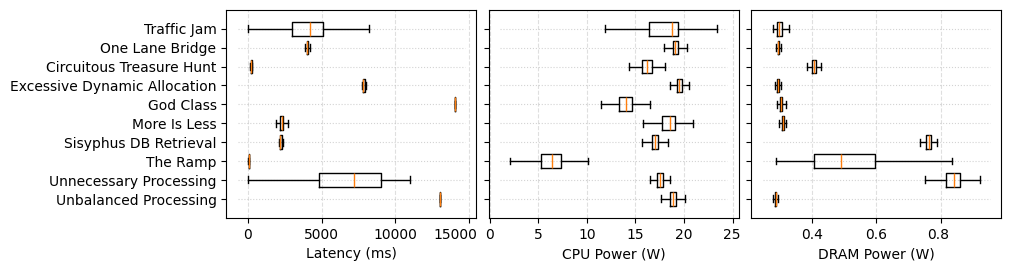

In [12]:
# Aggregate boxplots using campaign-level CSVs (30 runs each) into one figure with shared x labels.
import numpy as np
import matplotlib.transforms as mtransforms
from pathlib import Path

label_map = {
    'unbalanced_processing': 'Unbalanced Processing',
    'unnecessary_processing': 'Unnecessary Processing',
    'the_ramp': 'The Ramp',
    'sisyphus_db_retrieval': 'Sisyphus DB Retrieval',
    'more_is_less': 'More Is Less',
    'godclass': 'God Class',
    'excessive_dynamic_allocation': 'Excessive Dynamic Allocation',
    'circuitous_treasure_hunt': 'Circuitous Treasure Hunt',
    'one_lane_bridge': 'One Lane Bridge',
    'traffic_jam': 'Traffic Jam',
}

experiments = list(label_map.keys())

def _label(name: str) -> str:
    return label_map.get(name, name.replace('_', ' ').title())

def _load_metric_from_campaign(name, column):
    base = Path('./executed/2026-ICSA-PE') / name
    campaign_csv = base / f"{name}.csv"
    if not campaign_csv.exists():
        return None
    df = pd.read_csv(campaign_csv)
    if column not in df.columns:
        return None
    series = pd.to_numeric(df[column], errors='coerce').dropna()
    if column in {'cpu_power', 'dram_w'}:
        series = series[series >= 0]
    return series

metrics = [
    ("latency", "Latency (ms)"),
    ("cpu_power", "CPU Power (W)"),
    ("dram_w", "DRAM Power (W)"),
]

spacing = 0.55
box_width = 0.40
positions_all = np.arange(len(experiments)) * spacing

fig, axes = plt.subplots(
    1, len(metrics), figsize=(10, 2.7), sharey=True, gridspec_kw={"wspace": 0.05}
)

for ax, (column, xlabel) in zip(axes, metrics):
    data = []
    pos = []
    for idx, name in enumerate(experiments):
        vals = _load_metric_from_campaign(name, column)
        if vals is None or vals.empty:
            continue
        data.append(vals)
        pos.append(positions_all[idx])
    if data:
        ax.boxplot(
            data,
            positions=pos,
            widths=box_width,
            showcaps=True,
            showfliers=False,
            showmeans=False,
            vert=False,
        )
        ax.margins(x=0.05)
        ax.set_xlabel(xlabel)
        x_min, x_max = ax.get_xlim()
        ax.hlines(pos, x_min, x_max, colors='lightgray', linestyles=':', linewidth=0.8, zorder=0)
    else:
        ax.text(0.5, 0.5, f'No {column} data', ha='center', va='center', transform=ax.transAxes)
    if ax is not axes[0]:
        ax.tick_params(labelleft=False)
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)

axes[0].set_yticks(positions_all)
axes[0].set_yticklabels([_label(name) for name in experiments])
axes[0].set_ylim(positions_all[0] - spacing, positions_all[-1] + spacing)

fig.tight_layout(pad=0.8, w_pad=0.3)
fig.canvas.draw()
pixel_shift = mtransforms.ScaledTranslation(6/72, 0, fig.dpi_scale_trans)
for ax in axes:
    labels = [lbl for lbl in ax.get_xticklabels() if lbl.get_text()]
    if not labels:
        continue
    last = labels[-2]
    last.set_horizontalalignment("right")
    last.set_transform(last.get_transform() + pixel_shift)
plt.savefig("boxplots_combined.pdf", format="pdf", bbox_inches="tight")
plt.show()
